# Phase 4 — Physical & Environmental Suitability

**Ontario Distribution-Connected Solar Siting | 10+ MW Projects**

Compute all parcel-level physical, environmental, and suitability attributes
required as inputs to Phase 5 scoring, triage, and GeoJSON export.

**Architecture** — Dual geometry: `gross_geom` (full parcel boundary from
`developable_parcels_{slug}`) and `buildable_geom` (unioned from
`developable_area_parcels_{slug}`). Environmental complexity flags use
`gross_geom`; physical suitability metrics use `buildable_geom`. Both stored
in PostGIS via SQL — geopandas never touches geometry after table creation.

**Input**
- `analysis.developable_area_parcels_{slug}` — buildable geometry fragments
- `analysis.developable_parcels_{slug}` — full parcel boundaries (gross_geom)
- `analysis.oem_county_{slug}` — OEM grid feeder zones (capacity, voltage)
- `environment.significant_ecological_area` — PSW, ANSI, wetlands, woodlands
- `environment.nhs_area` — Natural Heritage System
- `environment.wildlife_activity_area`, `environment.wildlife_activity_site`
- `environment.prov_trk_species` — SARO species ranges
- `environment.cli` — Canadian Land Inventory
- `rea.{CONSERVATION_AUTH}_regulated_area` — CA regulated area
- `environment.flood_hazard` (optional per county)
- `cadastre.buildings_{slug}` — noise receptor count
- Rasters: DEM (slope), PVout (irradiance)

**Output** — `analysis.parcels_phase4_{slug}` with spec schema:
`parcel_id`, `gross_geom`, `buildable_geom`, areas, grid attributes
(`grid_mw`, `feeder_voltage_kv`, `oem_grid_summary`),
8 ECI flags (weighted), `eci_raw`, `env_risk_score`, `ca_overlap_ratio`,
SARO counts, physical metrics, triage classification.

**Steps**
1. Create base table (union fragments + attach gross_geom)
1b. OEM grid enrichment (spatial join against oem_county feeder zones)
2. ECI environmental flags (8 flags against gross/buildable per split rule)
3. SARO species counts (deduplicated)
4. CA authority overlap ratio (against gross_geom)
5. ECI weighted sum + env_risk_score
6. Raster statistics (PVout, slope, compactness, noise receptors)
7. Triage classification (GREEN / AMBER / RED)
8. Validation & interactive map

---
Change only `COUNTY_NAME`, `CONSERVATION_AUTH`, `DEM_PATH`, `PVOUT_PATH`,
and `FLOOD_TABLE` in the Configuration cell to reproduce for any county.

## 0 · Configuration

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# PROJECT PARAMETERS — edit this cell only to run for a different county
# ─────────────────────────────────────────────────────────────────────────────

import os

COUNTY_NAME       = "Oxford"          # Must match adm_district_township.name_2
CONSERVATION_AUTH = "utrca"            # orca (PTB) | rvca (OTT) | utrca (OXF)

# Parcel ID column names in Phase 3 output tables
# Default: "parcel_ogf_id" / "ogf_id"  (standard OGF cadastre)
# Legacy (Peterborough): set both to "parcel_id"
DAP_PARCEL_COL = "parcel_ogf_id"      # column in developable_area_parcels_{slug}
DP_PARCEL_COL  = "ogf_id"             # column in developable_parcels_{slug}

# Raster paths — GeoTIFF in EPSG:5321
DEM_PATH   = "data/rasters/dem_oxford_5321.tif"
PVOUT_PATH = "data/rasters/pvout_ontario_5321.tif"

# Flood hazard table — set None if not available for county
FLOOD_TABLE = None   # e.g. "environment.flood_hazard"

# PostGIS connection
PG_CONN = os.environ["POSTGRES_CONNECTION_STRING"]

# Output schema
OUTPUT_SCHEMA = "analysis"

# CRS
CRS_WGS84   = 4326
CRS_NAD83   = 4269   # NAD83 geographic — bridge CRS
CRS_ONTARIO = 5321   # NAD83(CSRS) / Ontario MNR Lambert — all calculations

# ── Derived constants ───────────────────────────────────────────────────────
county_slug = COUNTY_NAME.lower().replace(" ", "_")

# ── Runtime sanity checks ──────────────────────────────────────────────────
import pathlib

_errors = []
if not DEM_PATH:
    _errors.append("DEM_PATH is not set")
elif not pathlib.Path(DEM_PATH).exists():
    _errors.append(f"DEM_PATH not found: {DEM_PATH}")

if not PVOUT_PATH:
    _errors.append("PVOUT_PATH is not set")
elif not pathlib.Path(PVOUT_PATH).exists():
    _errors.append(f"PVOUT_PATH not found: {PVOUT_PATH}")

if _errors:
    for e in _errors:
        print(f"  ⚠️  {e}")
    print("\nSet DEM_PATH and PVOUT_PATH before running Step 6.")
else:
    print("  ✅  Raster paths verified.")

print(f"County            : {COUNTY_NAME} (slug: {county_slug})")
print(f"Conservation auth : {CONSERVATION_AUTH}")
print(f"Flood table       : {FLOOD_TABLE}")
print(f"Parcel ID cols    : DAP={DAP_PARCEL_COL}, DP={DP_PARCEL_COL}")

  ✅  Raster paths verified.
County            : Oxford (slug: oxford)
Conservation auth : utrca
Flood table       : None
Parcel ID cols    : DAP=parcel_ogf_id, DP=ogf_id


## 0 · Environment Setup & Utilities

In [16]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import geopandas as gpd
import pandas as pd
import folium
from folium.plugins import MiniMap
from sqlalchemy import create_engine, text

engine = create_engine(PG_CONN)


def read_postgis(sql: str, geom_col: str = "geom") -> gpd.GeoDataFrame:
    """Execute a PostGIS query and return a WGS84 GeoDataFrame."""
    gdf = gpd.read_postgis(sql, engine, geom_col=geom_col)
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=CRS_WGS84)
    return gdf.to_crs(epsg=CRS_WGS84)


def save_to_postgis(gdf: gpd.GeoDataFrame, table: str, label: str) -> None:
    """Write a GeoDataFrame to PostGIS in EPSG:5321 and create a GiST spatial index."""
    geom_col = gdf.geometry.name
    gdf.to_crs(epsg=CRS_ONTARIO).to_postgis(
        name=table,
        con=engine,
        schema=OUTPUT_SCHEMA,
        if_exists="replace",
        index=False,
        chunksize=500
    )
    with engine.connect() as conn:
        conn.execute(text(
            f"CREATE INDEX IF NOT EXISTS {table}_geom_idx "
            f"ON {OUTPUT_SCHEMA}.{table} USING GIST({geom_col})"
        ))
        conn.commit()
    print(f"  {label:40s} → {OUTPUT_SCHEMA}.{table} "
          f"({len(gdf):,} rows, EPSG:{CRS_ONTARIO}, GiST index)")


def update_parcels_phase4(records, col_defs, join_col="parcel_id"):
    """
    Merge scalar columns into analysis.parcels_phase4_{slug} using
    SQL ALTER TABLE + UPDATE via a temp table. Geometry is never touched.

    records : list of dicts or DataFrame — must include join_col
    col_defs: list of "col_name type" strings, e.g. ["pvout_mean float", "slope_mean float"]
    """
    table = f"parcels_phase4_{county_slug}"
    tmp   = "_tmp_p4_update"

    if isinstance(records, pd.DataFrame):
        df = records
    else:
        df = pd.DataFrame(records)

    if df.empty:
        print(f"  update_parcels_phase4: nothing to update (empty records)")
        return

    cols = [c for c in df.columns if c != join_col]

    df.to_sql(tmp, engine, schema=OUTPUT_SCHEMA, if_exists="replace", index=False)
    with engine.connect() as conn:
        for col_def in col_defs:
            parts = col_def.strip().split(None, 1)
            col_name = parts[0]
            col_type = parts[1] if len(parts) > 1 else "text"
            conn.execute(text(
                f'ALTER TABLE {OUTPUT_SCHEMA}.{table} '
                f'ADD COLUMN IF NOT EXISTS "{col_name}" {col_type}'
            ))

        set_cl = ", ".join(f'"{c}" = t."{c}"' for c in cols)
        conn.execute(text(
            f'UPDATE {OUTPUT_SCHEMA}.{table} p SET {set_cl} '
            f'FROM {OUTPUT_SCHEMA}.{tmp} t '
            f'WHERE p."{join_col}" = t."{join_col}"'
        ))
        conn.execute(text(f"DROP TABLE IF EXISTS {OUTPUT_SCHEMA}.{tmp}"))
        conn.commit()
    print(f"  update parcels_phase4_{county_slug}: {len(df):,} rows, cols={cols}")


def _table_exists(schema: str, table: str) -> bool:
    """Check whether a table exists in the given schema."""
    with engine.connect() as conn:
        return conn.execute(text(
            "SELECT EXISTS (SELECT 1 FROM information_schema.tables "
            "WHERE table_schema = :s AND table_name = :t)"
        ), {"s": schema, "t": table}).scalar()


def _column_exists(schema: str, table: str, column: str) -> bool:
    """Check whether a column exists in the given table."""
    with engine.connect() as conn:
        return conn.execute(text(
            "SELECT EXISTS (SELECT 1 FROM information_schema.columns "
            "WHERE table_schema = :s AND table_name = :t AND column_name = :c)"
        ), {"s": schema, "t": table, "c": column}).scalar()


def _get_srid(schema: str, table: str, geom_col: str = "geom") -> int:
    """Get the SRID of a geometry column."""
    with engine.connect() as c:
        srid = c.execute(text(
            f"SELECT ST_SRID({geom_col}) FROM {schema}.{table} LIMIT 1"
        )).scalar()
    return srid or 4326


print(f"County : {COUNTY_NAME} (slug: {county_slug})")
with engine.connect() as conn:
    print("PostGIS:", conn.execute(text("SELECT PostGIS_Full_Version()")).scalar())

County : Oxford (slug: oxford)
PostGIS: POSTGIS="3.6.1 0" [EXTENSION] PGSQL="170" GEOS="3.14.1-CAPI-1.20.5" SFCGAL="SFCGAL 2.2.0, CGAL 6.1, BOOST 1.79.0" PROJ="9.7.1 NETWORK_ENABLED=OFF URL_ENDPOINT=https://cdn.proj.org USER_WRITABLE_DIRECTORY=/tmp/proj DATABASE_PATH=/usr/local/pgsql/share/proj/proj.db" (compiled against PROJ 9.7.1) GDAL="GDAL 3.12.1 "Chicoutimi", released 2025/12/12" LIBXML="2.11.5" LIBJSON="0.17" LIBPROTOBUF="1.5.0" WAGYU="0.5.0 (Internal)" TOPOLOGY RASTER


---
## Step 1 — Create Phase 4 Base Table

Union buildable fragments per parcel from `developable_area_parcels_{slug}`.
Attach `gross_geom` (full parcel boundary) from `developable_parcels_{slug}`.
Extract best-feeder `grid_mw` and `feeder_voltage_kv` as floats.

Creates `analysis.parcels_phase4_{slug}` with dual geometry:
- `gross_geom` — full pre-exclusion parcel boundary (for ECI flags)
- `buildable_geom` — post-exclusion buildable area (for physical metrics)
- Scalar fields: `buildable_area_ha`, `buildable_area_ac`, `grid_mw`, `feeder_voltage_kv`, `main_address`, `township`

In [17]:
# Step 1 — Create Phase 4 base table with dual geometry
with engine.connect() as conn:
    conn.execute(text(f"DROP TABLE IF EXISTS {OUTPUT_SCHEMA}.parcels_phase4_{county_slug}"))
    conn.execute(text(f"""
        CREATE TABLE {OUTPUT_SCHEMA}.parcels_phase4_{county_slug} AS
        WITH buildable AS (
            SELECT
                {DAP_PARCEL_COL} AS parcel_id,
                ST_MakeValid(ST_Union(geom))  AS buildable_geom,
                ROUND((ST_Area(ST_MakeValid(ST_Union(geom))) / 10000.0)::numeric, 3)
                    AS buildable_area_ha,
                ROUND((ST_Area(ST_MakeValid(ST_Union(geom))) / 4046.856)::numeric, 3)
                    AS buildable_area_ac
            FROM {OUTPUT_SCHEMA}.developable_area_parcels_{county_slug}
            GROUP BY {DAP_PARCEL_COL}
        )
        SELECT
            b.parcel_id,
            dp.geom                 AS gross_geom,
            b.buildable_geom,
            b.buildable_area_ha,
            b.buildable_area_ac,
            dp.main_address,
            dp.township
        FROM buildable b
        JOIN {OUTPUT_SCHEMA}.developable_parcels_{county_slug} dp
            ON dp.{DP_PARCEL_COL} = b.parcel_id
    """))
    # Indexes
    conn.execute(text(
        f"ALTER TABLE {OUTPUT_SCHEMA}.parcels_phase4_{county_slug} "
        f"ADD PRIMARY KEY (parcel_id)"
    ))
    conn.execute(text(
        f"CREATE INDEX ON {OUTPUT_SCHEMA}.parcels_phase4_{county_slug} "
        f"USING GIST (gross_geom)"
    ))
    conn.execute(text(
        f"CREATE INDEX ON {OUTPUT_SCHEMA}.parcels_phase4_{county_slug} "
        f"USING GIST (buildable_geom)"
    ))
    conn.commit()

# Verify
row_count = pd.read_sql(
    f"SELECT COUNT(*) AS n FROM {OUTPUT_SCHEMA}.parcels_phase4_{county_slug}", engine
).iloc[0]["n"]
area_total = pd.read_sql(
    f"SELECT ROUND(SUM(buildable_area_ac)::numeric, 1) AS total "
    f"FROM {OUTPUT_SCHEMA}.parcels_phase4_{county_slug}", engine
).iloc[0]["total"]

print(f"Step 1 — Phase 4 base table for '{COUNTY_NAME}':")
print(f"  Table             : {OUTPUT_SCHEMA}.parcels_phase4_{county_slug}")
print(f"  Parcel count      : {row_count:,}")
print(f"  Buildable area    : {area_total:,} ac total")
# Verify dual geometry CRS
srid_check = pd.read_sql(f"""
    SELECT ST_SRID(gross_geom) AS gross_srid, ST_SRID(buildable_geom) AS build_srid
    FROM {OUTPUT_SCHEMA}.parcels_phase4_{county_slug} LIMIT 1
""", engine).iloc[0]
print(f"  gross_geom SRID   : {srid_check['gross_srid']}")
print(f"  buildable_geom SRID: {srid_check['build_srid']}")

Step 1 — Phase 4 base table for 'Oxford':
  Table             : analysis.parcels_phase4_oxford
  Parcel count      : 21
  Buildable area    : 1,678.9 ac total
  gross_geom SRID   : 5321
  buildable_geom SRID: 5321


### Step 1b — OEM Grid Enrichment

Spatial join against `analysis.oem_county_{slug}` to enrich each parcel with
grid connection attributes. Each OEM polygon represents a feeder service area
with a capacity (MW) and three-phase voltage (kV).

| Column | Source |
|---|---|
| `grid_mw` | MAX(capacity) across all intersecting OEM zones |
| `feeder_voltage_kv` | voltage_3ph of the max-capacity feeder |
| `oem_grid_summary` | All available feeders ranked by capacity DESC |

In [18]:
# Step 1b — OEM grid enrichment from analysis.oem_county_{slug}
oem_table = f"{OUTPUT_SCHEMA}.oem_county_{county_slug}"

with engine.connect() as conn:
    # Check OEM table exists
    oem_exists = conn.execute(text(
        "SELECT EXISTS (SELECT 1 FROM information_schema.tables "
        "WHERE table_schema = :schema AND table_name = :tbl)"
    ), {"schema": OUTPUT_SCHEMA, "tbl": f"oem_county_{county_slug}"}).scalar()

    if not oem_exists:
        print(f"⚠ OEM table {oem_table} not found — grid_mw / feeder_voltage_kv will be NULL")
        conn.execute(text(f"""
            ALTER TABLE {OUTPUT_SCHEMA}.parcels_phase4_{county_slug}
            ADD COLUMN IF NOT EXISTS grid_mw         double precision,
            ADD COLUMN IF NOT EXISTS feeder_voltage_kv double precision,
            ADD COLUMN IF NOT EXISTS oem_grid_summary  text
        """))
        conn.commit()
    else:
        # Add columns
        conn.execute(text(f"""
            ALTER TABLE {OUTPUT_SCHEMA}.parcels_phase4_{county_slug}
            ADD COLUMN IF NOT EXISTS grid_mw          double precision,
            ADD COLUMN IF NOT EXISTS feeder_voltage_kv double precision,
            ADD COLUMN IF NOT EXISTS oem_grid_summary  text
        """))

        # Spatial join: all OEM zones intersecting each parcel's gross_geom
        # Rank feeders by capacity DESC; pick the top for grid_mw/feeder_voltage_kv
        conn.execute(text(f"""
            WITH oem_hits AS (
                SELECT
                    p.parcel_id,
                    o.station_name,
                    o.feeder_name,
                    o.capacity,
                    o.voltage_3ph,
                    o.ldc_name,
                    ROW_NUMBER() OVER (
                        PARTITION BY p.parcel_id
                        ORDER BY o.capacity DESC NULLS LAST
                    ) AS rn
                FROM {OUTPUT_SCHEMA}.parcels_phase4_{county_slug} p
                JOIN {oem_table} o
                  ON ST_Intersects(p.gross_geom, o.geom)
            ),
            summary AS (
                SELECT
                    parcel_id,
                    MAX(CASE WHEN rn = 1 THEN capacity END)      AS grid_mw,
                    MAX(CASE WHEN rn = 1 THEN voltage_3ph END)   AS feeder_voltage_kv,
                    STRING_AGG(
                        COALESCE(station_name, '?') || '/' ||
                        COALESCE(feeder_name, '?')  || ': ' ||
                        COALESCE(capacity::text, '?') || ' MW @ ' ||
                        COALESCE(voltage_3ph::text, '?') || ' kV',
                        ' | ' ORDER BY capacity DESC NULLS LAST
                    ) AS oem_grid_summary
                FROM oem_hits
                GROUP BY parcel_id
            )
            UPDATE {OUTPUT_SCHEMA}.parcels_phase4_{county_slug} p
            SET grid_mw          = s.grid_mw,
                feeder_voltage_kv = s.feeder_voltage_kv,
                oem_grid_summary  = s.oem_grid_summary
            FROM summary s
            WHERE p.parcel_id = s.parcel_id
        """))
        conn.commit()

        # Verify
        oem_stats = pd.read_sql(f"""
            SELECT
                COUNT(*)                                 AS total,
                COUNT(grid_mw)                           AS has_grid,
                ROUND(MAX(grid_mw)::numeric, 1)          AS max_mw,
                ROUND(MIN(grid_mw)::numeric, 1)          AS min_mw,
                ROUND(MAX(feeder_voltage_kv)::numeric, 1) AS max_kv,
                ROUND(MIN(feeder_voltage_kv)::numeric, 1) AS min_kv
            FROM {OUTPUT_SCHEMA}.parcels_phase4_{county_slug}
        """, engine).iloc[0]

        print(f"Step 1b — OEM Grid Enrichment from {oem_table}:")
        print(f"  Parcels with grid data: {oem_stats['has_grid']}/{oem_stats['total']}")
        print(f"  grid_mw range         : {oem_stats['min_mw']} – {oem_stats['max_mw']} MW")
        print(f"  feeder_voltage range  : {oem_stats['min_kv']} – {oem_stats['max_kv']} kV")

        # Show sample summary
        sample = pd.read_sql(f"""
            SELECT parcel_id, grid_mw, feeder_voltage_kv,
                   LEFT(oem_grid_summary, 120) AS summary_preview
            FROM {OUTPUT_SCHEMA}.parcels_phase4_{county_slug}
            WHERE oem_grid_summary IS NOT NULL
            ORDER BY grid_mw DESC NULLS LAST
            LIMIT 3
        """, engine)
        print(f"\n  Top 3 parcels by grid_mw:")
        for _, r in sample.iterrows():
            print(f"    {int(r['parcel_id'])}: {r['grid_mw']} MW @ {r['feeder_voltage_kv']} kV — {r['summary_preview']}")

Step 1b — OEM Grid Enrichment from analysis.oem_county_oxford:
  Parcels with grid data: 21.0/21.0
  grid_mw range         : 16.2 – 19.0 MW
  feeder_voltage range  : 27.6 – 27.6 kV

  Top 3 parcels by grid_mw:
    1907907752: 19.0 MW @ 27.6 kV — INGERSOLL TS/M43: 19 MW @ 27.6 kV | INGERSOLL TS/M44: 18.9 MW @ 27.6 kV
    1907913723: 19.0 MW @ 27.6 kV — INGERSOLL TS/M43: 19 MW @ 27.6 kV | INGERSOLL TS/M43: 19 MW @ 27.6 kV
    1907914197: 19.0 MW @ 27.6 kV — INGERSOLL TS/M43: 19 MW @ 27.6 kV


---
## Step 2 — ECI Environmental Flags

8 weighted flags computed via PostGIS spatial joins. Each flag stores its weight directly
(0 = absent, weight = present). Environmental flags use `gross_geom`; flood uses `buildable_geom`;
SARO proximity uses `ST_Centroid(buildable_geom)`.

| Flag | Weight | Geometry | Source |
|---|---|---|---|
| `flag_wetland` | 3 | `gross_geom` | SEA subtype ILIKE '%Wetland%' |
| `flag_woodland` | 3 | `gross_geom` | SEA subtype ILIKE '%Woodland%' |
| `flag_nhs` | 2 | `gross_geom` | `nhs_area` |
| `flag_waa` | 2 | `gross_geom` | `wildlife_activity_area` / `wildlife_activity_site` |
| `flag_ca_regulated` | 3 | `gross_geom` | `{CA}_regulated_area` |
| `flag_flood` | 3 | `buildable_geom` | flood_hazard (if available) |
| `flag_cli_12` | 1 | `gross_geom` | CLI class 1 or 2 |
| `flag_saro_prox` | 2 | `ST_Centroid(buildable_geom)` | SARO species within 500m |

Also computes scratch columns `flag_psw` and `flag_ansi` for triage RED checks.

In [19]:
# Step 2 — ECI Environmental Flags (weighted)
# Per-flag UPDATEs to avoid cartesian-product explosion.
# Transform env table geom to match CRS_ONTARIO (keeps GiST index on p4).

flag_cols = [
    "flag_wetland int", "flag_woodland int", "flag_nhs int",
    "flag_saro_prox int", "flag_waa int", "flag_ca_regulated int",
    "flag_flood int", "flag_cli_12 int",
    "flag_psw int", "flag_ansi int",  # scratch columns for triage
]

# Check which env tables exist
has_sea   = _table_exists("environment", "significant_ecological_area")
has_nhs   = _table_exists("environment", "nhs_area")
has_waa   = _table_exists("environment", "wildlife_activity_area")
has_was   = _table_exists("environment", "wildlife_activity_site")
has_cli   = _table_exists("environment", "cli")
has_ca    = _table_exists("rea", f"{CONSERVATION_AUTH}_regulated_area")
has_saro  = _table_exists("environment", "prov_trk_species")
has_flood = (FLOOD_TABLE and _table_exists(
    FLOOD_TABLE.split(".")[0], FLOOD_TABLE.split(".")[1]
)) if FLOOD_TABLE else False

print(f"  significant_ecological_area: {has_sea}")
print(f"  nhs_area                   : {has_nhs}")
print(f"  wildlife_activity_area     : {has_waa}")
print(f"  wildlife_activity_site     : {has_was}")
print(f"  cli                        : {has_cli}")
print(f"  {CONSERVATION_AUTH}_regulated_area: {has_ca}")
print(f"  prov_trk_species           : {has_saro}")
print(f"  flood_hazard ({FLOOD_TABLE}): {has_flood}")

p4_table = f"{OUTPUT_SCHEMA}.parcels_phase4_{county_slug}"

with engine.connect() as conn:
    # Add all flag columns with default 0
    for col_def in flag_cols:
        parts = col_def.strip().split(None, 1)
        conn.execute(text(
            f'ALTER TABLE {p4_table} '
            f'ADD COLUMN IF NOT EXISTS "{parts[0]}" {parts[1]} DEFAULT 0'
        ))
    conn.execute(text(f"""
        UPDATE {p4_table} SET
            flag_wetland = 0, flag_woodland = 0, flag_nhs = 0,
            flag_saro_prox = 0, flag_waa = 0, flag_ca_regulated = 0,
            flag_flood = 0, flag_cli_12 = 0, flag_psw = 0, flag_ansi = 0
    """))

    # ── flag_wetland (3) + flag_woodland (3) + flag_psw + flag_ansi — via gross_geom ──
    if has_sea:
        sea_srid = _get_srid("environment", "significant_ecological_area")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET flag_wetland  = sub.f_wetland,
                flag_woodland = sub.f_woodland,
                flag_psw      = sub.f_psw,
                flag_ansi     = sub.f_ansi
            FROM (
                SELECT p.parcel_id,
                    CASE WHEN MAX(CASE WHEN sea.subtype ILIKE '%%Wetland%%'
                                      THEN 1 ELSE 0 END) = 1 THEN 3 ELSE 0 END  AS f_wetland,
                    CASE WHEN MAX(CASE WHEN sea.subtype ILIKE '%%Woodland%%'
                                      THEN 1 ELSE 0 END) = 1 THEN 3 ELSE 0 END  AS f_woodland,
                    MAX(CASE WHEN sea.subtype ILIKE '%%Provincially Significant%%'
                             THEN 1 ELSE 0 END)                                  AS f_psw,
                    MAX(CASE WHEN sea.subtype ILIKE '%%ANSI%%'
                             THEN 1 ELSE 0 END)                                  AS f_ansi
                FROM {p4_table} p
                JOIN environment.significant_ecological_area sea
                    ON ST_Intersects(ST_Transform(p.gross_geom, {sea_srid}), sea.geom)
                GROUP BY p.parcel_id
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
        print("    flag_wetland/woodland/psw/ansi: done")

    # ── flag_nhs (2) — via gross_geom ──
    if has_nhs:
        nhs_srid = _get_srid("environment", "nhs_area")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET flag_nhs = 2
            FROM (
                SELECT DISTINCT p.parcel_id
                FROM {p4_table} p
                JOIN environment.nhs_area nhs
                    ON ST_Intersects(ST_Transform(p.gross_geom, {nhs_srid}), nhs.geom)
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
        print("    flag_nhs: done")

    # ── flag_waa (2) — via gross_geom (union of wildlife_activity_area + wildlife_activity_site) ──
    if has_waa:
        waa_srid = _get_srid("environment", "wildlife_activity_area")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET flag_waa = 2
            FROM (
                SELECT DISTINCT p.parcel_id
                FROM {p4_table} p
                JOIN environment.wildlife_activity_area waa
                    ON ST_Intersects(ST_Transform(p.gross_geom, {waa_srid}), waa.geom)
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
        print("    flag_waa (area): done")

    if has_was:
        was_srid = _get_srid("environment", "wildlife_activity_site")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET flag_waa = 2
            FROM (
                SELECT DISTINCT p.parcel_id
                FROM {p4_table} p
                JOIN environment.wildlife_activity_site was
                    ON ST_Intersects(ST_Transform(p.gross_geom, {was_srid}), was.geom)
                WHERE p.flag_waa = 0
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
        print("    flag_waa (site): done")

    # ── flag_ca_regulated (3) — via gross_geom ──
    if has_ca:
        ca_srid = _get_srid("rea", f"{CONSERVATION_AUTH}_regulated_area")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET flag_ca_regulated = 3
            FROM (
                SELECT DISTINCT p.parcel_id
                FROM {p4_table} p
                JOIN rea.{CONSERVATION_AUTH}_regulated_area ca
                    ON ST_Intersects(ST_Transform(p.gross_geom, {ca_srid}), ca.geom)
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
        print("    flag_ca_regulated: done")

    # ── flag_flood (3) — via buildable_geom ──
    if has_flood:
        flood_parts = FLOOD_TABLE.split(".")
        flood_srid = _get_srid(flood_parts[0], flood_parts[1])
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET flag_flood = 3
            FROM (
                SELECT DISTINCT p.parcel_id
                FROM {p4_table} p
                JOIN {FLOOD_TABLE} fh
                    ON ST_Intersects(ST_Transform(p.buildable_geom, {flood_srid}), fh.geom)
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
        print("    flag_flood: done")

    # ── flag_cli_12 (1) — via gross_geom ──
    if has_cli:
        cli_srid = _get_srid("environment", "cli")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET flag_cli_12 = 1
            FROM (
                SELECT DISTINCT p.parcel_id
                FROM {p4_table} p
                JOIN environment.cli cli
                    ON ST_Intersects(ST_Transform(p.gross_geom, {cli_srid}), cli.geom)
                WHERE cli.cli_sys LIKE '1%%' OR cli.cli_sys LIKE '2%%'
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
        print("    flag_cli_12: done")

    # ── flag_saro_prox (2) — ST_DWithin 500m from ST_Centroid(buildable_geom) ──
    if has_saro:
        saro_srid = _get_srid("environment", "prov_trk_species")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET flag_saro_prox = 2
            FROM (
                SELECT DISTINCT p.parcel_id
                FROM {p4_table} p
                JOIN environment.prov_trk_species ts
                    ON ST_DWithin(
                        ST_Centroid(p.buildable_geom),
                        ST_Transform(ts.geom, {CRS_ONTARIO}),
                        500
                    )
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
        print("    flag_saro_prox: done")

    conn.commit()

# Verify
df_flags = pd.read_sql(f"""
    SELECT
        COUNT(*) FILTER (WHERE flag_wetland > 0)      AS wetland,
        COUNT(*) FILTER (WHERE flag_woodland > 0)      AS woodland,
        COUNT(*) FILTER (WHERE flag_nhs > 0)           AS nhs,
        COUNT(*) FILTER (WHERE flag_saro_prox > 0)     AS saro_prox,
        COUNT(*) FILTER (WHERE flag_waa > 0)           AS waa,
        COUNT(*) FILTER (WHERE flag_ca_regulated > 0)  AS ca_reg,
        COUNT(*) FILTER (WHERE flag_flood > 0)         AS flood,
        COUNT(*) FILTER (WHERE flag_cli_12 > 0)        AS cli_12,
        COUNT(*) FILTER (WHERE flag_psw > 0)           AS psw,
        COUNT(*) FILTER (WHERE flag_ansi > 0)          AS ansi,
        COUNT(*) AS total
    FROM {p4_table}
""", engine)
r = df_flags.iloc[0]
print(f"\nStep 2 — ECI flags for '{COUNTY_NAME}':")
print(f"  flag_wetland      : {r['wetland']:,} / {r['total']:,}  (wt=3)")
print(f"  flag_woodland     : {r['woodland']:,}  (wt=3)")
print(f"  flag_nhs          : {r['nhs']:,}  (wt=2)")
print(f"  flag_saro_prox    : {r['saro_prox']:,}  (wt=2)")
print(f"  flag_waa          : {r['waa']:,}  (wt=2)")
print(f"  flag_ca_regulated : {r['ca_reg']:,}  (wt=3)")
print(f"  flag_flood        : {r['flood']:,}  (wt=3)")
print(f"  flag_cli_12       : {r['cli_12']:,}  (wt=1)")
print(f"  flag_psw (scratch): {r['psw']:,}")
print(f"  flag_ansi(scratch): {r['ansi']:,}")

  significant_ecological_area: True
  nhs_area                   : True
  wildlife_activity_area     : True
  wildlife_activity_site     : True
  cli                        : True
  utrca_regulated_area: True
  prov_trk_species           : True
  flood_hazard (None): False
    flag_wetland/woodland/psw/ansi: done
    flag_nhs: done
    flag_waa (area): done
    flag_waa (site): done
    flag_ca_regulated: done
    flag_cli_12: done
    flag_saro_prox: done

Step 2 — ECI flags for 'Oxford':
  flag_wetland      : 0 / 21  (wt=3)
  flag_woodland     : 0  (wt=3)
  flag_nhs          : 0  (wt=2)
  flag_saro_prox    : 21  (wt=2)
  flag_waa          : 0  (wt=2)
  flag_ca_regulated : 19  (wt=3)
  flag_flood        : 0  (wt=3)
  flag_cli_12       : 21  (wt=1)
  flag_psw (scratch): 0
  flag_ansi(scratch): 0


---
## Step 3 — SARO Species Counts

Join `environment.prov_trk_species` against `gross_geom` (full parcel boundary).
Deduplicate species by `common_nam` per parcel before counting.

Output: `saro_end_count`, `saro_thr_count`, `saro_sc_count` (integers).
Used by Phase 5 SARO scoring (END → RED flag + 5pt penalty; score = 15 − THR×2 − SC×1).

In [20]:
# Step 3 — SARO Species Counts (deduplicated, against gross_geom)
p4_table = f"{OUTPUT_SCHEMA}.parcels_phase4_{county_slug}"
has_saro = _table_exists("environment", "prov_trk_species")
print(f"SARO table 'environment.prov_trk_species' exists: {has_saro}")

saro_col_defs = ["saro_end_count int", "saro_thr_count int", "saro_sc_count int"]

with engine.connect() as conn:
    for col_def in saro_col_defs:
        parts = col_def.strip().split(None, 1)
        conn.execute(text(
            f'ALTER TABLE {p4_table} '
            f'ADD COLUMN IF NOT EXISTS "{parts[0]}" {parts[1]} DEFAULT 0'
        ))

    if has_saro:
        saro_srid = _get_srid("environment", "prov_trk_species")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET saro_end_count = sub.end_count,
                saro_thr_count = sub.thr_count,
                saro_sc_count  = sub.sc_count
            FROM (
                WITH distinct_spp AS (
                    SELECT DISTINCT p.parcel_id, ts.common_nam, ts.saro_statu
                    FROM {p4_table} p
                    JOIN environment.prov_trk_species ts
                        ON ST_Intersects(
                            ST_Transform(p.gross_geom, {saro_srid}),
                            ts.geom
                        )
                )
                SELECT
                    parcel_id,
                    COUNT(*) FILTER (WHERE saro_statu = 'END')  AS end_count,
                    COUNT(*) FILTER (WHERE saro_statu = 'THR')  AS thr_count,
                    COUNT(*) FILTER (WHERE saro_statu = 'SC')   AS sc_count
                FROM distinct_spp
                GROUP BY parcel_id
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
    conn.commit()

# Verify
df_saro = pd.read_sql(f"""
    SELECT
        COUNT(*) FILTER (WHERE saro_end_count > 0)  AS with_end,
        COUNT(*) FILTER (WHERE saro_thr_count > 0)  AS with_thr,
        COUNT(*) FILTER (WHERE saro_sc_count > 0)   AS with_sc,
        COUNT(*) AS total
    FROM {p4_table}
""", engine)
r = df_saro.iloc[0]
print(f"Step 3 — SARO counts for '{COUNTY_NAME}':")
print(f"  Parcels with END : {r['with_end']:,} / {r['total']:,}")
print(f"  Parcels with THR : {r['with_thr']:,}")
print(f"  Parcels with SC  : {r['with_sc']:,}")

SARO table 'environment.prov_trk_species' exists: True
Step 3 — SARO counts for 'Oxford':
  Parcels with END : 6 / 21
  Parcels with THR : 10
  Parcels with SC  : 18


---
## Step 4 — CA Authority Overlap Ratio

Overlap between **gross parcel boundary** (`gross_geom`) and CA regulated area.
CA regulates the full parcel, not just the buildable footprint.

$$ca\_overlap = \frac{ST\_Area(gross\_geom \cap CA)}{ST\_Area(gross\_geom)}$$

Parcels with no CA intersection → 0.0. Used for triage: ≥ 0.60 → RED.

In [21]:
# Step 4 — CA Authority Overlap Ratio (against gross_geom)
p4_table = f"{OUTPUT_SCHEMA}.parcels_phase4_{county_slug}"
has_ca = _table_exists("rea", f"{CONSERVATION_AUTH}_regulated_area")
print(f"CA table 'rea.{CONSERVATION_AUTH}_regulated_area' exists: {has_ca}")

with engine.connect() as conn:
    conn.execute(text(
        f'ALTER TABLE {p4_table} '
        f'ADD COLUMN IF NOT EXISTS ca_overlap_ratio float DEFAULT 0.0'
    ))

    if has_ca:
        ca_srid = _get_srid("rea", f"{CONSERVATION_AUTH}_regulated_area")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET ca_overlap_ratio = ROUND(
                COALESCE(
                    ST_Area(ST_Intersection(
                        ST_Transform(p4.gross_geom, {ca_srid}),
                        ca.geom
                    )) / NULLIF(ST_Area(ST_Transform(p4.gross_geom, {ca_srid})), 0),
                    0.0
                )::numeric, 4)
            FROM (
                SELECT p.parcel_id,
                    ST_Union(ca_r.geom) AS geom
                FROM {p4_table} p
                JOIN rea.{CONSERVATION_AUTH}_regulated_area ca_r
                    ON ST_Intersects(
                        ST_Transform(p.gross_geom, {ca_srid}),
                        ca_r.geom
                    )
                GROUP BY p.parcel_id
            ) ca
            WHERE p4.parcel_id = ca.parcel_id
        """))

    # Parcels with no CA intersection remain NULL → set to 0.0
    conn.execute(text(
        f"UPDATE {p4_table} SET ca_overlap_ratio = 0.0 WHERE ca_overlap_ratio IS NULL"
    ))
    conn.commit()

# Verify
df_ca = pd.read_sql(f"""
    SELECT
        COUNT(*) FILTER (WHERE ca_overlap_ratio > 0)    AS with_overlap,
        COUNT(*) FILTER (WHERE ca_overlap_ratio >= 0.6)  AS high_overlap,
        ROUND(AVG(ca_overlap_ratio)::numeric, 4)         AS mean_overlap,
        COUNT(*) AS total
    FROM {p4_table}
""", engine)
r = df_ca.iloc[0]
print(f"Step 4 — CA overlap ratio for '{COUNTY_NAME}':")
print(f"  Parcels with overlap > 0  : {r['with_overlap']:,} / {r['total']:,}")
print(f"  Parcels with overlap ≥ 0.6: {r['high_overlap']:,}")
print(f"  Mean overlap ratio        : {r['mean_overlap']}")

CA table 'rea.utrca_regulated_area' exists: True
Step 4 — CA overlap ratio for 'Oxford':
  Parcels with overlap > 0  : 19.0 / 21.0
  Parcels with overlap ≥ 0.6: 0.0
  Mean overlap ratio        : 0.1069


---
## Step 5 — ECI Weighted Sum + Environmental Risk Score

`eci_raw` = simple sum of all 8 weighted flags (max possible = 19).
`env_risk_score` = inverse-scaled to 0–15 points for Phase 5 scoring.

$$env\_risk\_score = \max\left(0,\ \left(1 - \frac{eci\_raw}{19}\right) \times 15\right)$$

Requires Steps 2, 3, and 4 complete.

In [22]:
# Step 5 — ECI Weighted Sum + Environmental Risk Score
p4_table = f"{OUTPUT_SCHEMA}.parcels_phase4_{county_slug}"

with engine.connect() as conn:
    conn.execute(text(
        f'ALTER TABLE {p4_table} ADD COLUMN IF NOT EXISTS eci_raw int'
    ))
    conn.execute(text(
        f'ALTER TABLE {p4_table} ADD COLUMN IF NOT EXISTS env_risk_score float'
    ))

    # eci_raw = sum of all 8 weighted flags (flags already store their weights)
    conn.execute(text(f"""
        UPDATE {p4_table}
        SET eci_raw = (
            COALESCE(flag_wetland,      0) +
            COALESCE(flag_woodland,     0) +
            COALESCE(flag_nhs,          0) +
            COALESCE(flag_saro_prox,    0) +
            COALESCE(flag_waa,          0) +
            COALESCE(flag_ca_regulated, 0) +
            COALESCE(flag_flood,        0) +
            COALESCE(flag_cli_12,       0)
        )
    """))

    # env_risk_score = GREATEST(0, (1 - eci_raw/19.0) * 15)
    conn.execute(text(f"""
        UPDATE {p4_table}
        SET env_risk_score = GREATEST(0, ROUND((1.0 - eci_raw / 19.0) * 15, 2))
    """))
    conn.commit()

# Verify
df_eci = pd.read_sql(f"""
    SELECT
        MIN(eci_raw) AS eci_min, MAX(eci_raw) AS eci_max,
        ROUND(AVG(eci_raw)::numeric, 2) AS eci_mean,
        COUNT(*) FILTER (WHERE eci_raw = 0) AS eci_clean,
        COUNT(*) FILTER (WHERE eci_raw >= 10) AS eci_high,
        MIN(env_risk_score) AS ers_min, MAX(env_risk_score) AS ers_max,
        ROUND(AVG(env_risk_score)::numeric, 2) AS ers_mean,
        COUNT(*) AS total
    FROM {p4_table}
""", engine)
r = df_eci.iloc[0]
print(f"Step 5 — ECI + env_risk_score for '{COUNTY_NAME}':")
print(f"  ECI range        : {r['eci_min']} – {r['eci_max']} (max possible: 19)")
print(f"  Mean ECI         : {r['eci_mean']}")
print(f"  ECI = 0 (clean)  : {r['eci_clean']:,} / {r['total']:,}")
print(f"  ECI ≥ 10 (high)  : {r['eci_high']:,}")
print(f"  env_risk_score   : {r['ers_min']} – {r['ers_max']} (mean {r['ers_mean']})")

Step 5 — ECI + env_risk_score for 'Oxford':
  ECI range        : 3.0 – 6.0 (max possible: 19)
  Mean ECI         : 5.71
  ECI = 0 (clean)  : 0.0 / 21.0
  ECI ≥ 10 (high)  : 0.0
  env_risk_score   : 10.26 – 12.63 (mean 10.49)


---
## Step 6 — Physical Metrics (Raster Stats, Compactness, Noise)

All computed against `buildable_geom` (construction footprint).

- **6a** — PVout zonal mean (kWh/kWp/day) via Rasterio windowed read
- **6b** — Slope zonal mean (%) via DEM gradient + `slope_gt8_pct` for triage
- **6c** — Polsby-Popper compactness ratio via PostGIS
- **6d** — Noise receptor count (buildings within 1 km of buildable centroid)

In [23]:
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import transform_geom as rio_transform_geom
from shapely.geometry import mapping

p4_table = f"{OUTPUT_SCHEMA}.parcels_phase4_{county_slug}"

# Load buildable geometries in EPSG:5321 for raster masking
gdf_p4 = read_postgis(
    f"SELECT parcel_id, buildable_geom FROM {p4_table}",
    geom_col="buildable_geom"
)
gdf_p4_5321 = gdf_p4.to_crs(epsg=CRS_ONTARIO)

# ── Step 6a — PVout zonal mean ───────────────────────────────────────────────
pvout_results = []
with rasterio.open(PVOUT_PATH) as src:
    raster_crs = str(src.crs)
    for _, row in gdf_p4_5321.iterrows():
        try:
            geom_dict = mapping(row.buildable_geom)
            if src.crs.to_epsg() != CRS_ONTARIO:
                geom_dict = rio_transform_geom(
                    f"EPSG:{CRS_ONTARIO}", raster_crs, geom_dict
                )
            out_image, _ = rio_mask(src, [geom_dict], crop=True, nodata=src.nodata)
            vals = out_image[0].astype(float).flatten()
            if src.nodata is not None:
                vals = vals[vals != src.nodata]
            vals = vals[~np.isnan(vals)]
            if len(vals) > 0:
                pvout_results.append({
                    "parcel_id":  row.parcel_id,
                    "pvout_mean": float(np.mean(vals)),
                })
            else:
                pvout_results.append({"parcel_id": row.parcel_id, "pvout_mean": None})
        except Exception:
            pvout_results.append({"parcel_id": row.parcel_id, "pvout_mean": None})

update_parcels_phase4(pd.DataFrame(pvout_results), ["pvout_mean float"])
df_pv = pd.DataFrame(pvout_results)
print(f"Step 6a — PVout for '{COUNTY_NAME}':")
print(f"  Valid parcels : {df_pv['pvout_mean'].notna().sum():,} / {len(df_pv):,}")
if df_pv['pvout_mean'].notna().any():
    print(f"  Mean PVout    : {df_pv['pvout_mean'].mean():.4f} kWh/kWp/day")

# ── Step 6b — Slope zonal mean + slope_gt8_pct ──────────────────────────────
slope_results = []
with rasterio.open(DEM_PATH) as src:
    raster_crs = str(src.crs)
    for _, row in gdf_p4_5321.iterrows():
        try:
            geom_dict = mapping(row.buildable_geom)
            if src.crs.to_epsg() != CRS_ONTARIO:
                geom_dict = rio_transform_geom(
                    f"EPSG:{CRS_ONTARIO}", raster_crs, geom_dict
                )
            out_image, out_transform = rio_mask(src, [geom_dict], crop=True,
                                                nodata=src.nodata, filled=True)
            elev = out_image[0].astype(float)
            if src.nodata is not None:
                elev[elev == src.nodata] = np.nan

            if np.all(np.isnan(elev)) or elev.size < 4:
                slope_results.append({"parcel_id": row.parcel_id,
                                      "slope_mean": None, "slope_gt8_pct": None})
                continue

            res_x = abs(out_transform.a)
            res_y = abs(out_transform.e)
            dy, dx = np.gradient(elev, res_y, res_x)
            slope_pct = np.sqrt(dx**2 + dy**2) * 100
            valid = ~np.isnan(elev)
            n_valid = valid.sum()
            if n_valid == 0:
                slope_results.append({"parcel_id": row.parcel_id,
                                      "slope_mean": None, "slope_gt8_pct": None})
            else:
                s_mean = float(np.nanmean(slope_pct[valid]))
                gt8_frac = float((slope_pct[valid] > 8).sum()) / n_valid
                slope_results.append({
                    "parcel_id":    row.parcel_id,
                    "slope_mean":   s_mean,
                    "slope_gt8_pct": round(gt8_frac, 4),
                })
        except Exception:
            slope_results.append({"parcel_id": row.parcel_id,
                                  "slope_mean": None, "slope_gt8_pct": None})

update_parcels_phase4(
    pd.DataFrame(slope_results),
    ["slope_mean float", "slope_gt8_pct float"]
)
df_sl = pd.DataFrame(slope_results)
print(f"\nStep 6b — Slope for '{COUNTY_NAME}':")
print(f"  Valid parcels : {df_sl['slope_mean'].notna().sum():,} / {len(df_sl):,}")
if df_sl['slope_mean'].notna().any():
    print(f"  Mean slope    : {df_sl['slope_mean'].mean():.2f} %%")

# ── Step 6c — Polsby-Popper Compactness ──────────────────────────────────────
with engine.connect() as conn:
    conn.execute(text(
        f'ALTER TABLE {p4_table} ADD COLUMN IF NOT EXISTS pp_ratio float'
    ))
    conn.execute(text(f"""
        UPDATE {p4_table}
        SET pp_ratio = ROUND(
            (4 * PI() * ST_Area(buildable_geom)
             / NULLIF(ST_Perimeter(buildable_geom) * ST_Perimeter(buildable_geom), 0)
            )::numeric, 4
        )
    """))
    conn.commit()

df_pp = pd.read_sql(
    f"SELECT AVG(pp_ratio) AS mean_pp, MIN(pp_ratio) AS min_pp, MAX(pp_ratio) AS max_pp "
    f"FROM {p4_table}", engine
)
print(f"\nStep 6c — Polsby-Popper compactness:")
print(f"  Mean PP : {df_pp.iloc[0]['mean_pp']:.4f}")
print(f"  Range   : [{df_pp.iloc[0]['min_pp']:.4f}, {df_pp.iloc[0]['max_pp']:.4f}]")

# ── Step 6d — Noise Receptors (buildings within 1km of buildable centroid) ───
has_buildings = _table_exists("cadastre", f"buildings_{county_slug}")
print(f"\nBuildings table 'cadastre.buildings_{county_slug}' exists: {has_buildings}")

with engine.connect() as conn:
    conn.execute(text(
        f'ALTER TABLE {p4_table} ADD COLUMN IF NOT EXISTS noise_count_1km int'
    ))

    if has_buildings:
        bld_srid = _get_srid("cadastre", f"buildings_{county_slug}")
        conn.execute(text(f"""
            UPDATE {p4_table} p4
            SET noise_count_1km = sub.cnt
            FROM (
                SELECT p.parcel_id, COUNT(b.geom) AS cnt
                FROM {p4_table} p
                LEFT JOIN cadastre.buildings_{county_slug} b
                    ON ST_DWithin(
                        ST_Transform(ST_Centroid(p.buildable_geom), {bld_srid}),
                        b.geom,
                        1000
                    )
                GROUP BY p.parcel_id
            ) sub
            WHERE p4.parcel_id = sub.parcel_id
        """))
    conn.commit()

if has_buildings:
    df_noise = pd.read_sql(
        f"SELECT AVG(noise_count_1km) AS mean_nr, MAX(noise_count_1km) AS max_nr "
        f"FROM {p4_table}", engine
    )
    print(f"Step 6d — Noise receptors:")
    print(f"  Mean buildings ≤1km : {df_noise.iloc[0]['mean_nr']:.1f}")
    print(f"  Max buildings ≤1km  : {df_noise.iloc[0]['max_nr']}")
else:
    print("  No buildings table — noise_count_1km = NULL for all parcels")

  update parcels_phase4_oxford: 21 rows, cols=['pvout_mean']
Step 6a — PVout for 'Oxford':
  Valid parcels : 13 / 21
  Mean PVout    : 3.6893 kWh/kWp/day
  update parcels_phase4_oxford: 21 rows, cols=['slope_mean', 'slope_gt8_pct']

Step 6b — Slope for 'Oxford':
  Valid parcels : 21 / 21
  Mean slope    : 3.18 %%

Step 6c — Polsby-Popper compactness:
  Mean PP : 0.4563
  Range   : [0.1072, 0.7780]

Buildings table 'cadastre.buildings_oxford' exists: True
Step 6d — Noise receptors:
  Mean buildings ≤1km : 62699.0
  Max buildings ≤1km  : 62699.0


---
## Step 7 — Triage Classification

Assign every parcel a traffic-light `triage_class` (GREEN / AMBER / RED).

**RED** (automatically excluded from scoring in Phase 5):
- END species present (`saro_end_count > 0`)
- PSW on gross parcel (`flag_psw > 0`)
- ANSI on gross parcel (`flag_ansi > 0`)
- `ca_overlap_ratio ≥ 0.60`
- Grid capacity ratio < 0.5: `(buildable_area_ac / 5) / grid_mw < 0.5`

**AMBER** (scored but flagged for remediation):
- Partial CA overlap (0 < ratio < 0.60)
- THR or SC species present
- NHS area on gross parcel (`flag_nhs > 0`)
- `slope_gt8_pct > 0.25` (>25% of buildable area has slope > 8%)
- `noise_count_1km IS NULL` (data gap) or `noise_count_1km > 8`
- Grid capacity ratio 0.50–0.70

**GREEN**: none of the above triggered.

Store `triage_flags` as PostgreSQL `TEXT[]` array. Also sets `data_completeness` and `analyst_note`.

In [24]:
# Step 7 — Triage Classification
p4_table = f"{OUTPUT_SCHEMA}.parcels_phase4_{county_slug}"

df = pd.read_sql(f"SELECT * FROM {p4_table}", engine)

def classify_triage(row):
    red_flags, amber_flags = [], []

    # ── RED conditions ──────────────────────────────────────────────────────
    if (row.get("saro_end_count") or 0) > 0:
        red_flags.append("END_SPECIES")
    if (row.get("flag_psw") or 0) > 0:
        red_flags.append("PSW_ON_GROSS_PARCEL")
    if (row.get("flag_ansi") or 0) > 0:
        red_flags.append("ANSI_ON_GROSS_PARCEL")
    if (row.get("ca_overlap_ratio") or 0) >= 0.60:
        red_flags.append("CA_REGULATED_GTE_60PCT")

    buildable_mw = (row.get("buildable_area_ac") or 0) / 5.0
    grid_mw = row.get("grid_mw") or 0
    grid_ratio = min(buildable_mw / grid_mw, 1.0) if grid_mw > 0 else 0.0
    if grid_mw > 0 and grid_ratio < 0.5:
        red_flags.append("GRID_RATIO_LT_0.5")

    # ── AMBER conditions ────────────────────────────────────────────────────
    if 0 < (row.get("ca_overlap_ratio") or 0) < 0.60:
        amber_flags.append("CA_REGULATED_PARTIAL")
    if (row.get("saro_thr_count") or 0) + (row.get("saro_sc_count") or 0) > 0:
        amber_flags.append("THR_SC_SPECIES")
    if (row.get("flag_nhs") or 0) > 0:
        amber_flags.append("NHS_ON_GROSS_PARCEL")
    slope_gt8 = row.get("slope_gt8_pct")
    if slope_gt8 is not None and pd.notna(slope_gt8) and float(slope_gt8) > 0.25:
        amber_flags.append("SLOPE_GT8_OVER_25PCT")
    noise = row.get("noise_count_1km")
    if noise is None or pd.isna(noise):
        amber_flags.append("NULL_NOISE_DATA_GAP")
    elif int(noise) > 8:
        amber_flags.append("NOISE_HIGH_GT8")
    if grid_mw > 0 and 0.50 <= grid_ratio < 0.70:
        amber_flags.append("GRID_RATIO_MARGINAL")

    if red_flags:
        return "RED", red_flags + amber_flags
    elif amber_flags:
        return "AMBER", amber_flags
    else:
        return "GREEN", []

df[["triage_class", "_triage_list"]] = df.apply(
    lambda r: pd.Series(classify_triage(r)), axis=1
)
# Convert list → PostgreSQL array literal: '{flag1,flag2}'
df["triage_flags"] = df["_triage_list"].apply(
    lambda x: "{" + ",".join(x) + "}" if x else "{}"
)
df.drop(columns=["_triage_list"], inplace=True)

# data_completeness
df["data_completeness"] = df.apply(lambda r: (
    "FULL_THREE_TIER"
    if pd.notna(r.get("grid_mw")) and pd.notna(r.get("pvout_mean"))
    else "PROVINCIAL_COUNTY"
    if pd.notna(r.get("pvout_mean"))
    else "PROVINCIAL_ONLY"
), axis=1)

# analyst_note — NULL initially
df["analyst_note"] = None

# Write scalar text columns via update_parcels_phase4
update_parcels_phase4(
    df[["parcel_id", "triage_class", "data_completeness", "analyst_note"]],
    ["triage_class text", "data_completeness text", "analyst_note text"]
)

# Write triage_flags as text[] via direct SQL (pandas to_sql can't handle array types)
with engine.connect() as conn:
    conn.execute(text(
        f'ALTER TABLE {p4_table} ADD COLUMN IF NOT EXISTS triage_flags text[]'
    ))
    # Build per-parcel UPDATE values
    for _, row in df[["parcel_id", "triage_flags"]].iterrows():
        conn.execute(text(
            f"UPDATE {p4_table} SET triage_flags = CAST(:flags AS text[]) "
            f"WHERE parcel_id = :pid"
        ), {"flags": row["triage_flags"], "pid": int(row["parcel_id"])})
    conn.commit()
print(f"  triage_flags written as text[] for {len(df):,} rows")

# Summary
counts = df["triage_class"].value_counts()
print(f"\nStep 7 — Triage classification for '{COUNTY_NAME}':")
print(f"  GREEN : {counts.get('GREEN', 0):,}")
print(f"  AMBER : {counts.get('AMBER', 0):,}")
print(f"  RED   : {counts.get('RED', 0):,}")
print(f"\n  data_completeness:")
print(df["data_completeness"].value_counts().to_string())

  update parcels_phase4_oxford: 21 rows, cols=['triage_class', 'data_completeness', 'analyst_note']
  triage_flags written as text[] for 21 rows

Step 7 — Triage classification for 'Oxford':
  GREEN : 0
  AMBER : 12
  RED   : 9

  data_completeness:
data_completeness
FULL_THREE_TIER    13
PROVINCIAL_ONLY     8


---
## Step 8 — Verification & Interactive Map

Field audit (null percentages), triage counts, ECI range, env_risk_score distribution,
CA overlap stats, flag value validation. Folium map coloured by `triage_class`
(GREEN / AMBER / RED) with tooltip showing key attributes.

Bar chart of triage_class distribution.

=== Phase 4 Field Audit ===
  Row count: 21
  parcel_id                      null=0%
  buildable_area_ha              null=0%
  buildable_area_ac              null=0%
  main_address                   null=0%
  township                       null=0%
  grid_mw                        null=0%
  feeder_voltage_kv              null=0%
  oem_grid_summary               null=0%
  flag_wetland                   null=0%
  flag_woodland                  null=0%
  flag_nhs                       null=0%
  flag_saro_prox                 null=0%
  flag_waa                       null=0%
  flag_ca_regulated              null=0%
  flag_flood                     null=0%
  flag_cli_12                    null=0%
  flag_psw                       null=0%
  flag_ansi                      null=0%
  saro_end_count                 null=0%
  saro_thr_count                 null=0%
  saro_sc_count                  null=0%
  ca_overlap_ratio               null=0%
  eci_raw                        null=0%
  env_risk_sc

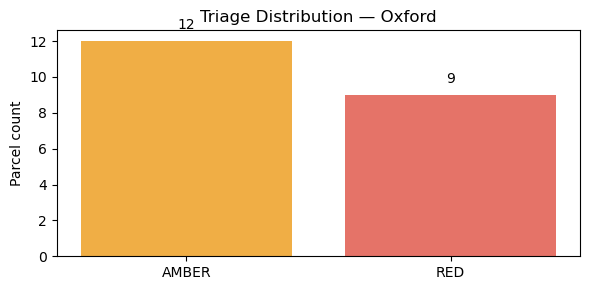


Saved: output/map_phase4_oxford.html


In [25]:
# Step 8 — Verification & Interactive Map
import matplotlib.pyplot as plt

p4_table = f"{OUTPUT_SCHEMA}.parcels_phase4_{county_slug}"

# ── Field Audit ──────────────────────────────────────────────────────────────
df_audit = pd.read_sql(f"SELECT * FROM {p4_table}", engine)
print("=== Phase 4 Field Audit ===")
print(f"  Row count: {len(df_audit):,}")
for col in df_audit.columns:
    if col in ("gross_geom", "buildable_geom"):
        continue
    null_pct = df_audit[col].isna().mean() * 100
    print(f"  {col:<30} null={null_pct:.0f}%")

# ── Triage Counts ────────────────────────────────────────────────────────────
print("\n=== Triage Counts ===")
print(df_audit["triage_class"].value_counts().to_string())

# ── ECI Distribution ─────────────────────────────────────────────────────────
print("\n=== ECI Raw Distribution ===")
print(df_audit["eci_raw"].describe().to_string())

# ── env_risk_score Distribution ──────────────────────────────────────────────
print("\n=== env_risk_score Distribution ===")
print(df_audit["env_risk_score"].describe().to_string())

# ── CA Overlap ───────────────────────────────────────────────────────────────
print("\n=== CA Overlap Ratio ===")
ca_subset = df_audit[df_audit["ca_overlap_ratio"] > 0]
if len(ca_subset) > 0:
    print(ca_subset["ca_overlap_ratio"].describe().to_string())
else:
    print("  No parcels with CA overlap > 0")

# ── Null noise count ─────────────────────────────────────────────────────────
null_noise = df_audit["noise_count_1km"].isna().sum()
print(f"\n  Null noise_count_1km: {null_noise:,} / {len(df_audit):,}")

# ── Flag value validation ────────────────────────────────────────────────────
print("\n=== Flag Value Validation ===")
for flag_col, expected_wt in [
    ("flag_wetland", 3), ("flag_woodland", 3), ("flag_nhs", 2),
    ("flag_saro_prox", 2), ("flag_waa", 2), ("flag_ca_regulated", 3),
    ("flag_flood", 3), ("flag_cli_12", 1),
]:
    if flag_col in df_audit.columns:
        vals = sorted(df_audit[flag_col].dropna().unique())
        ok = all(v in (0, expected_wt) for v in vals)
        print(f"  {flag_col:<20} values={vals}  expected={{0,{expected_wt}}}  {'✅' if ok else '❌'}")

# ── Triage Bar Chart ─────────────────────────────────────────────────────────
TRIAGE_COLORS = {"GREEN": "#4caf7d", "AMBER": "#f0ae45", "RED": "#e57368"}
counts = df_audit["triage_class"].value_counts()
fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.bar(counts.index, counts.values,
              color=[TRIAGE_COLORS.get(c, "#999") for c in counts.index])
ax.set_title(f"Triage Distribution — {COUNTY_NAME}")
ax.set_ylabel("Parcel count")
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

# ── Interactive Map ──────────────────────────────────────────────────────────
gdf_map = read_postgis(
    f"SELECT parcel_id, buildable_geom, triage_class, buildable_area_ac, grid_mw, "
    f"feeder_voltage_kv, slope_mean, pvout_mean, noise_count_1km, pp_ratio, "
    f"ca_overlap_ratio, eci_raw, env_risk_score, saro_end_count, saro_thr_count, "
    f"saro_sc_count, main_address "
    f"FROM {p4_table}",
    geom_col="buildable_geom"
)

TRIAGE_OUTLINE = {"GREEN": "#2e6b47", "AMBER": "#c77c0a", "RED": "#c0392b"}
TRIAGE_FILL    = {"GREEN": "#4caf7d", "AMBER": "#f0ae45", "RED": "#e57368"}

center = [gdf_map.geometry.centroid.y.mean(), gdf_map.geometry.centroid.x.mean()]
m = folium.Map(location=center, zoom_start=10, tiles=None)
MiniMap(toggle_display=True).add_to(m)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri, Maxar, Earthstar Geographics, and the GIS User Community",
    name="Esri World Imagery",
    max_zoom=19,
).add_to(m)

# REA exclusion layer (context)
try:
    gdf_rea = read_postgis(
        f"SELECT geom FROM {OUTPUT_SCHEMA}.rea_exclusions_{county_slug}"
    )
    folium.GeoJson(
        gdf_rea.__geo_interface__,
        name="REA exclusion zones",
        style_function=lambda _: {
            "fillColor": "#89dd59", "color": "#0e4908",
            "weight": 0.5, "fillOpacity": 0.18
        }
    ).add_to(m)
except Exception:
    pass

tooltip_fields = [
    "parcel_id", "main_address", "triage_class",
    "buildable_area_ac", "grid_mw", "feeder_voltage_kv",
    "slope_mean", "pvout_mean", "noise_count_1km",
    "pp_ratio", "ca_overlap_ratio", "eci_raw", "env_risk_score",
    "saro_end_count", "saro_thr_count", "saro_sc_count",
]
tooltip_aliases = [
    "Parcel ID", "Address", "Triage Class",
    "Buildable Area (ac)", "Grid MW", "Voltage (kV)",
    "Mean Slope (%)", "PVout (kWh/kWp/day)", "Buildings ≤1 km",
    "Polsby-Popper", "CA Overlap", "ECI Raw", "Env Risk Score",
    "END Count", "THR Count", "SC Count",
]
present_pairs = [(f, a) for f, a in zip(tooltip_fields, tooltip_aliases)
                 if f in gdf_map.columns]
p_fields, p_aliases = zip(*present_pairs) if present_pairs else ([], [])

for tc in ["GREEN", "AMBER", "RED"]:
    subset = gdf_map[gdf_map["triage_class"] == tc]
    if subset.empty:
        continue
    folium.GeoJson(
        subset.__geo_interface__,
        name=f"Parcels — {tc} ({len(subset):,})",
        style_function=lambda _, c=TRIAGE_OUTLINE[tc], f=TRIAGE_FILL[tc]: {
            "fillColor": f, "color": c, "weight": 1.5, "fillOpacity": 0.7
        },
        highlight_function=lambda _, c=TRIAGE_OUTLINE[tc]: {
            "color": c, "weight": 3, "fillOpacity": 0.9
        },
        tooltip=folium.GeoJsonTooltip(
            fields=list(p_fields),
            aliases=list(p_aliases),
            localize=True, sticky=True
        )
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

out_html = f"output/map_phase4_{county_slug}.html"
m.save(out_html)
print(f"\nSaved: {out_html}")